# Notebook 3: Hitter Ability Score Construction

## Purpose

The objective of this notebook is to construct a single measure of overall MLB hitting ability that can be used as the target variable for the machine learning models developed later in this project.

Previous analysis identified four MLB offensive metrics that collectively represent different dimensions of offensive performance:

- **OBP** – Ability to consistently reach base.
- **ISO** – Power production independent of batting average.
- **wOBA** – Overall offensive value based on weighted offensive events.
- **wRC+** – Adjusted offensive production relative to league average.

Rather than predicting each statistic individually, these metrics will be combined into a single **Hitter Ability Score (HAS)**. This approach provides a more comprehensive representation of offensive talent while reducing redundancy among highly correlated statistics.

Three methods for constructing the Hitter Ability Score will be evaluated:

1. **Equal-Weighted Composite Score**
2. **Baseball-Weighted Composite Score**
3. **Principal Component Analysis (PCA)**

Each method will be compared based on statistical properties, baseball interpretability, and predictive performance. The most appropriate Hitter Ability Score will then be selected as the final target variable for the machine learning models developed in the next phase of the project.

## Load the Final Modeling Dataset

The first step is to load the finalized modeling dataset created during the previous notebook. This dataset contains the selected Minor League predictor variables along with the four MLB offensive metrics that will be used to construct the Hitter Ability Score.

Before creating the composite scores, the distributions and summary statistics of these four metrics will be examined to better understand the data.

In [1]:
import pandas as pd
import numpy as np

# Load the finalized modeling dataset
prospectml = pd.read_csv("C:\\Users\\ncodi\\OneDrive\\Documents\\ProspectML\\Data\\prospectml_model_data.csv")

prospectml.head()

,PlayerID,AAA_Age,AAA_BB%,AAA_ISO,AAA_K%,AAA_OPS,AAA_SLG,AA_Age,AA_BB%,AA_ISO,...,Career_wOBA,Career_wRC_plus,HighA_Age,HighA_BB%,HighA_ISO,HighA_K%,MLB_OBP,MLB_ISO,MLB_wOBA,MLB_wRC_plus
0,paulo_orlando,25-33,6.2,0.136,18.0,0.733,0.408,24-31,6.3,0.144,...,0.328,92,21-23,4.6,0.129,20.2,0.289,0.121,0.290,78
1,gorkys_hernandez,23-31,9.4,0.113,22.1,0.722,0.380,21-22,7.1,0.073,...,0.330,102,20-20,10.3,0.123,16.9,0.292,0.121,0.281,74
2,pedro_florimon,25-34,10.1,0.131,27.1,0.715,0.384,22-31,9.2,0.107,...,0.318,93,22-31,8.5,0.152,21.9,0.270,0.108,0.262,59
3,ivan_de_jesus_jr,23-32,8.3,0.112,17.2,0.775,0.412,21-32,13.8,0.102,...,0.351,103,20-20,11.4,0.093,12.7,0.303,0.085,0.279,71
4,matt_davidson,22-30,9.3,0.213,28.7,0.783,0.458,21-21,12.0,0.208,...,0.350,104,19-20,9.3,0.178,24.9,0.290,0.209,0.308,93


## Summary Statistics of the MLB Offensive Metrics

Before combining the selected offensive metrics into a single Hitter Ability Score, it is useful to examine their distributions and ranges.

Because these statistics are measured on different scales, they cannot be combined directly. Understanding their descriptive statistics also provides context for the standardization process used in the following sections.

In [2]:
mlb_stats = [
    "MLB_OBP",
    "MLB_ISO",
    "MLB_wOBA",
    "MLB_wRC_plus"
]

prospectml[mlb_stats].describe().T

,count,mean,std,min,25%,50%,75%,max
MLB_OBP,936.0,0.311403,0.025534,0.225,0.294,0.312,0.32800,0.413
MLB_ISO,936.0,0.147655,0.043874,0.029,0.117,0.148,0.17825,0.322
MLB_wOBA,936.0,0.306922,0.026865,0.225,0.289,0.308,0.32500,0.425
MLB_wRC_plus,936.0,91.355769,18.922542,34.000,79.000,92.000,103.00000,178.000


## Correlation Between Selected MLB Metrics

Although these four offensive metrics were chosen because they represent different aspects of hitting ability, they are still expected to be related.

Examining their correlations provides a final confirmation of the relationships among the selected metrics before constructing the Hitter Ability Score.

In [3]:
prospectml[mlb_stats].corr().round(3)

,MLB_OBP,MLB_ISO,MLB_wOBA,MLB_wRC_plus
MLB_OBP,1.000,0.299,0.857,0.825
MLB_ISO,0.299,1.000,0.713,0.717
MLB_wOBA,0.857,0.713,1.000,0.970
MLB_wRC_plus,0.825,0.717,0.970,1.000


## Standardizing the Offensive Metrics

The four offensive metrics selected for this project are measured on different numerical scales.

For example, OBP and wOBA are proportions that typically range between 0.250 and 0.450, ISO generally ranges between 0.050 and 0.350, while wRC+ is centered around 100 and often ranges from approximately 50 to 180.

Because of these differences, the metrics cannot be combined directly. If they were averaged in their original form, statistics with larger numerical scales would dominate the resulting score regardless of their relative importance.

To ensure that each offensive metric contributes appropriately to the Hitter Ability Score, each variable will first be standardized using z-score normalization. This transformation centers each metric at a mean of zero and scales it by its standard deviation, allowing all variables to be compared on a common scale.

In [4]:
from scipy.stats import zscore

prospectml["OBP_z"] = zscore(prospectml["MLB_OBP"])
prospectml["ISO_z"] = zscore(prospectml["MLB_ISO"])
prospectml["wOBA_z"] = zscore(prospectml["MLB_wOBA"])
prospectml["wRCplus_z"] = zscore(prospectml["MLB_wRC_plus"])

## Verifying the Standardization

A correctly standardized variable should have:

- a mean approximately equal to 0
- a standard deviation approximately equal to 1

The following summary statistics verify that each offensive metric has been successfully standardized before constructing the Hitter Ability Score.

In [5]:
zscore_columns = [
    "OBP_z",
    "ISO_z",
    "wOBA_z",
    "wRCplus_z"
]

prospectml[zscore_columns].agg(["mean", "std"]).round(3)

,OBP_z,ISO_z,wOBA_z,wRCplus_z
mean,-0.000,-0.000,0.000,0.000
std,1.001,1.001,1.001,1.001


## Method 1: Equal-Weighted Hitter Ability Score

The first approach constructs the Hitter Ability Score by assigning equal importance to each of the four standardized offensive metrics.

Because each metric has already been standardized using z-score normalization, they are measured on the same numerical scale. This allows them to be averaged directly without any single statistic dominating the composite score due to differences in magnitude.

This method assumes that each offensive metric contributes equally to a player's overall hitting ability and serves as the baseline approach against which more advanced methods will be compared.

In [6]:
prospectml["HAS_equal"] = (
    prospectml["OBP_z"] +
    prospectml["ISO_z"] +
    prospectml["wOBA_z"] +
    prospectml["wRCplus_z"]
) / 4

## Evaluating the Equal-Weighted Score

The distribution of the Equal-Weighted Hitter Ability Score is examined to ensure that the resulting composite score is well-behaved and provides reasonable separation among players.

Summary statistics and a histogram are used to evaluate the score before comparing it with the alternative construction methods.

In [7]:
prospectml["HAS_equal"].describe()

count    9.360000e+02
mean    -9.109522e-17
std      8.935480e-01
min     -2.650857e+00
25%     -6.319664e-01
50%      2.291272e-02
75%      5.680172e-01
max      4.233983e+00
Name: HAS_equal, dtype: float64

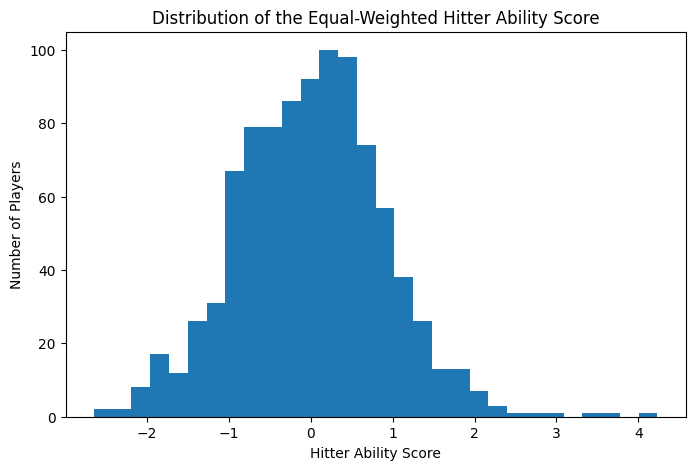

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(prospectml["HAS_equal"], bins=30)

plt.title("Distribution of the Equal-Weighted Hitter Ability Score")
plt.xlabel("Hitter Ability Score")
plt.ylabel("Number of Players")

plt.show()

In [9]:
prospectml[
    ["PlayerID", "HAS_equal"]
].sort_values(
    "HAS_equal",
    ascending=False
).head(10)

,PlayerID,HAS_equal
674,aaron_judge,4.233983
743,mike_trout,3.604866
835,yordan_alvarez,3.324188
782,joey_votto,2.871316
822,ronald_acuna_jr,2.628108
566,freddie_freeman,2.437880
723,paul_goldschmidt,2.279276
746,mookie_betts,2.202787
698,giancarlo_stanton,2.194782
368,kyle_tucker,2.115394


In [10]:
prospectml[
    ["PlayerID", "HAS_equal"]
].sort_values(
    "HAS_equal"
).head(10)

,PlayerID,HAS_equal
42,michael_martinez,-2.650857
249,brandon_wood,-2.567575
429,cristian_pache,-2.278824
758,koyie_hill,-2.213573
179,magneuris_sierra,-2.163372
131,andrew_velazquez,-2.114701
432,drew_butera,-2.105067
730,nick_allen,-2.080818
917,jeff_mathis,-2.027342
544,tomas_nido,-1.987255


### Initial Evaluation

The Equal-Weighted Hitter Ability Score produced player rankings that were consistent with expectations based on MLB offensive performance.

An inspection of the highest- and lowest-ranked players suggested that the score successfully distinguished stronger offensive hitters from weaker offensive hitters. While this qualitative evaluation does not determine whether the Equal-Weighted approach is the optimal method, it provides initial evidence that the composite score is capturing meaningful differences in offensive ability.

The Equal-Weighted Hitter Ability Score will now be compared with alternative construction methods to determine whether a different weighting strategy provides a more accurate representation of overall hitting ability.

## Method 2: Baseball-Informed Hitter Ability Score

The second approach constructs the Hitter Ability Score using a weighted combination of the four standardized offensive metrics.

Unlike the Equal-Weighted method, this approach assigns greater importance to statistics that represent overall offensive performance while assigning smaller weights to statistics that measure individual offensive skills.

The weighting scheme was informed by the feature selection and target evaluation performed in the previous notebook. During that analysis, wOBA and wRC+ were identified as the strongest comprehensive measures of offensive ability, while OBP and ISO were retained because they capture distinct offensive skills that are not fully represented by the broader metrics.

The following weights were selected:

- **wRC+:** 35%
- **wOBA:** 35%
- **OBP:** 15%
- **ISO:** 15%

This weighting strategy emphasizes complete offensive value while still allowing on-base ability and power production to contribute independently to the overall Hitter Ability Score.

In [11]:
prospectml["HAS_weighted"] = (
    0.15 * prospectml["OBP_z"] +
    0.15 * prospectml["ISO_z"] +
    0.35 * prospectml["wOBA_z"] +
    0.35 * prospectml["wRCplus_z"]
)

## Evaluating the Baseball-Informed Score

The Baseball-Informed Hitter Ability Score is evaluated using the same procedures as the Equal-Weighted approach.

Examining the distribution and player rankings allows the impact of the weighting strategy to be assessed before comparing it with the Equal-Weighted and Principal Component Analysis methods.

In [12]:
prospectml["HAS_weighted"].describe()

count    9.360000e+02
mean     2.277381e-16
std      9.321030e-01
min     -2.807268e+00
25%     -6.358850e-01
50%      3.002375e-02
75%      5.877087e-01
max      4.336187e+00
Name: HAS_weighted, dtype: float64

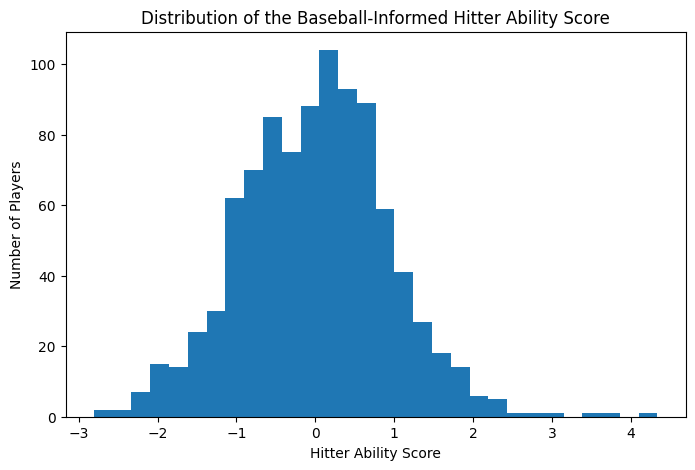

In [13]:
plt.figure(figsize=(8,5))

plt.hist(prospectml["HAS_weighted"], bins=30)

plt.title("Distribution of the Baseball-Informed Hitter Ability Score")
plt.xlabel("Hitter Ability Score")
plt.ylabel("Number of Players")

plt.show()

In [14]:
prospectml[
    ["PlayerID", "HAS_weighted"]
].sort_values(
    "HAS_weighted",
    ascending=False
).head(10)

,PlayerID,HAS_weighted
674,aaron_judge,4.336187
743,mike_trout,3.720085
835,yordan_alvarez,3.460363
782,joey_votto,2.938699
822,ronald_acuna_jr,2.712035
566,freddie_freeman,2.539504
723,paul_goldschmidt,2.357349
746,mookie_betts,2.293432
698,giancarlo_stanton,2.251385
368,kyle_tucker,2.202557


In [15]:
prospectml[
    ["PlayerID", "HAS_weighted"]
].sort_values(
    "HAS_weighted"
).head(10)

,PlayerID,HAS_weighted
42,michael_martinez,-2.807268
249,brandon_wood,-2.713803
429,cristian_pache,-2.405006
758,koyie_hill,-2.390867
179,magneuris_sierra,-2.254996
432,drew_butera,-2.236840
131,andrew_velazquez,-2.233242
917,jeff_mathis,-2.182757
252,isan_diaz,-2.159012
730,nick_allen,-2.145140


In [16]:
prospectml[["HAS_equal", "HAS_weighted"]].corr()

,HAS_equal,HAS_weighted
HAS_equal,1.000000,0.999006
HAS_weighted,0.999006,1.000000


## Method 3: Principal Component Analysis (PCA)

The final approach constructs the Hitter Ability Score using Principal Component Analysis (PCA).

Unlike the previous methods, PCA does not require manually selecting weights. Instead, it identifies the linear combination of the selected offensive metrics that explains the greatest amount of variation in offensive performance across all players.

The first principal component represents the direction of maximum variance within the data and can therefore be interpreted as a single measure of overall offensive ability. The resulting component scores will be used as the PCA-based Hitter Ability Score.

This approach provides a fully data-driven alternative to the Equal-Weighted and Baseball-Informed methods.

In [17]:
from sklearn.decomposition import PCA

In [18]:
pca_features = [
    "OBP_z",
    "ISO_z",
    "wOBA_z",
    "wRCplus_z"
]

X = prospectml[pca_features]

In [19]:
pca = PCA(n_components=1)

prospectml["HAS_pca"] = pca.fit_transform(X)

## Variance Explained

The proportion of variance explained by the first principal component indicates how much of the information contained within the four offensive metrics is summarized by a single composite score.

Higher values indicate that one underlying offensive ability factor successfully captures most of the variation across the selected metrics.

In [20]:
print(f"Variance Explained: {pca.explained_variance_ratio_[0]:.3%}")

Variance Explained: 80.750%


## PCA Variance Explained

The first principal component explained **80.750%** of the total variance among the selected MLB offensive metrics.

This indicates that a single underlying offensive factor captures the majority of the information contained within OBP, ISO, wOBA, and wRC+. While each statistic provides unique information regarding different aspects of offensive performance, most of the variation among these metrics is driven by a common measure of overall hitting ability.

The strong variance explained supports the use of a single composite Hitter Ability Score as a representation of overall offensive performance.

## Principal Component Loadings

The component loadings represent the contribution of each standardized offensive metric to the PCA-based Hitter Ability Score.

Unlike the Baseball-Informed method, these weights are determined entirely from the structure of the data rather than being assigned manually.

In [21]:
pca_weights = pd.DataFrame({
    "Metric": pca_features,
    "Weight": pca.components_[0]
})

pca_weights

,Metric,Weight
0,OBP_z,0.470751
1,ISO_z,0.415773
2,wOBA_z,0.552318
3,wRCplus_z,0.548152


## PCA Component Loadings

The PCA loadings provide insight into how each offensive metric contributes to the data-driven Hitter Ability Score.

The first principal component assigned the largest weights to wOBA and wRC+, followed by OBP and ISO. This suggests that the data independently identified the comprehensive offensive metrics as the strongest contributors to overall hitting ability.

The PCA loadings closely align with the Baseball-Informed weighting strategy, where greater emphasis was placed on wOBA and wRC+ due to their ability to summarize overall offensive value. This agreement between a domain-informed approach and a fully data-driven approach provides additional confidence that the selected offensive metrics are appropriately representing overall hitting ability.

In [22]:
prospectml[
    [
        "HAS_equal",
        "HAS_weighted",
        "HAS_pca"
    ]
].corr()

,HAS_equal,HAS_weighted,HAS_pca
HAS_equal,1.000000,0.999006,0.999658
HAS_weighted,0.999006,1.000000,0.999582
HAS_pca,0.999658,0.999582,1.000000


## Comparing Hitter Ability Score Construction Methods

The three Hitter Ability Score construction methods were compared to determine whether different weighting strategies produced meaningfully different evaluations of offensive ability.

The Equal-Weighted, Baseball-Informed, and PCA-based scores demonstrated an extremely high level of agreement. The correlation between the Baseball-Informed and PCA-based approaches was approximately **0.9996**, indicating that the two methods produced nearly identical player evaluations.

This result suggests that the selected offensive metrics contain a strong underlying offensive ability factor. Because the different construction methods produced nearly identical rankings, the final Hitter Ability Score selection was based primarily on interpretability and alignment with baseball analysis rather than differences in statistical output.

The Baseball-Informed Hitter Ability Score was selected as the final metric because it maintains the statistical consistency of the alternative approaches while incorporating domain knowledge into the weighting process.

In [23]:
prospectml["Hitter_Ability_Score"] = prospectml["HAS_weighted"]

## Creating the Final Percentile-Based Hitter Ability Score

The Baseball-Informed Hitter Ability Score is converted into a percentile-based 0-100 scale for improved interpretability.

Instead of measuring a player's distance between the highest and lowest performers in the dataset, the percentile transformation measures a player's relative standing compared to the rest of the population.

This allows the final score to be interpreted similarly to scouting grades, where higher values indicate that a player ranks above a larger percentage of comparable hitters.

For example, a score of 90 indicates that a player performed better than approximately 90% of hitters in the dataset.

In [24]:
prospectml["Hitter_Ability_Score"] = (
    prospectml["HAS_weighted"]
    .rank(pct=True)
    * 100
)

In [25]:
prospectml["Hitter_Ability_Score"].describe()

count    936.000000
mean      50.053419
std       28.882930
min        0.106838
25%       25.080128
50%       50.053419
75%       75.026709
max      100.000000
Name: Hitter_Ability_Score, dtype: float64

In [26]:
prospectml[
    [
        "HAS_weighted",
        "Hitter_Ability_Score"
    ]
].corr()

,HAS_weighted,Hitter_Ability_Score
HAS_weighted,1.00000,0.96712
Hitter_Ability_Score,0.96712,1.00000


## Final Hitter Ability Score Selection

After comparing the Equal-Weighted, Baseball-Informed, and PCA approaches, all three methods produced nearly identical evaluations of player offensive ability. The Baseball-Informed Hitter Ability Score was selected as the final analytical metric because it provides a balance between statistical consistency and baseball interpretability.

The continuous **HAS_weighted** value will be retained for modeling purposes. Maintaining the original continuous score preserves the full variation between players and allows machine learning models to predict differences in offensive ability more precisely.

For scouting and player evaluation purposes, a percentile-based version of the score will also be maintained. The percentile transformation provides a more intuitive 0-100 scale, allowing coaches, scouts, and decision-makers to quickly understand a player's relative offensive standing within the dataset.

Therefore:

- **HAS_weighted:** Used as the continuous target variable for modeling.
- **Hitter_Ability_Score:** Used as the percentile-based scouting display metric.

This approach preserves statistical information for analysis while creating a more accessible evaluation tool for baseball audiences.

## Export Final Modeling Dataset

The finalized dataset is exported for use in the machine learning phase of the project.

This dataset contains the selected Minor League predictor variables, the retained MLB offensive target metrics, the Baseball-Informed Hitter Ability Score (`HAS_weighted`), and the percentile-based scouting display score (`Hitter_Ability_Score`).

The exported dataset will serve as the input for Notebook 4, where machine learning models will be trained to predict future MLB offensive ability from Minor League performance.

In [27]:
prospectml = prospectml.drop(
    columns=[
        "HAS_equal",
        "HAS_pca"
    ]
)

In [28]:
prospectml.to_csv(
    "../data/prospectml_final.csv",
    index=False
)